# Exploration vs Exploitation Analysis using Multi-Armed Bandit Algorithm

**Comparison:** two *policies* solving the same 10-armed bandit problem under identical
conditions.

- **Exploration Policy** → ε-Greedy (ε = 0.10, occasionally tries random arms)
- **Exploitation Policy** → Greedy (ε = 0.00, always picks the current best-known arm)

```
Initialize Environment
        |
        v
Create 10-Armed Bandit
        |
        v
Run Exploration Policy (epsilon-Greedy)
        |
        v
Run Exploitation Policy (Greedy)
        |
        v
Compare Performance
        |
        v
Summary Table
        |
        v
Visualizations
```


## Cell 1 — Libraries & Environment Setup

```
Import Libraries
      |
      v
Random Seed
      |
      v
Create 10-Armed Bandit
      |
      v
Initialize Reward Probabilities
      |
      v
Initialize Counters
      |
      v
Set Number of Episodes
      |
      v
Display Initial Parameters
```


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

%matplotlib inline
plt.rcParams['figure.facecolor'] = 'white'

# ---------------------------------------------------------------
# Random Seed
# ---------------------------------------------------------------
SEED = 42
np.random.seed(SEED)

# ---------------------------------------------------------------
# Create 10-Armed Bandit
# ---------------------------------------------------------------
N_ARMS = 10
EPISODES = 1000
EPSILON = 0.10

# ---------------------------------------------------------------
# Initialize Reward Probabilities (true, unknown to the agent)
# Each arm i pays a reward of 1 with probability reward_probabilities[i], else 0
# ---------------------------------------------------------------
reward_probabilities = np.random.uniform(0.1, 0.9, size=N_ARMS)
true_best_arm = int(np.argmax(reward_probabilities))  # kept hidden from the agent

# ---------------------------------------------------------------
# Initialize Counters (populated once the policies run in Cell 2)
# ---------------------------------------------------------------
# Q  -> estimated action-value per arm
# N  -> number of times each arm has been pulled

# ---------------------------------------------------------------
# Display Initial Parameters
# ---------------------------------------------------------------
initial_params = pd.DataFrame({
    "Parameter": ["Number of Arms", "Episodes", "Exploration Rate (epsilon)",
                  "Random Seed", "Best Arm"],
    "Value": [N_ARMS, EPISODES, f"{EPSILON:.2f}", SEED, "Hidden"]
})

print("Multi-Armed Bandit Environment Initialized")
print("=" * 45)
initial_params


Multi-Armed Bandit Environment Initialized


,Parameter,Value
0,Number of Arms,10
1,Episodes,1000
2,Exploration Rate (epsilon),0.10
3,Random Seed,42
4,Best Arm,Hidden


## Cell 2 — Algorithm & Policy Comparison

```
Part A                          Part B
------                          ------
Exploration                     Exploitation
   |                               |
   v                               v
epsilon-Greedy Policy           Greedy Policy
   |                               |
   v                               v
Choose Random / Best Arm        Choose Best Arm
   |                               |
   v                               v
Receive Reward                  Receive Reward
   |                               |
   v                               v
Update Average Reward           Update Average Reward
   |                               |
   v                               v
Repeat                          Repeat
------------------------------------------
                Compare
```

Both policies are run with the **same underlying bandit** (`reward_probabilities`) and the
same number of episodes, so the comparison is apples-to-apples. The Greedy policy is simply
the epsilon-Greedy routine run with `epsilon = 0`.


In [2]:
def run_bandit_policy(reward_probabilities, episodes, epsilon, seed):
    """
    Runs an epsilon-Greedy bandit policy (epsilon = 0 reduces it to pure Greedy).

    Returns a dictionary with per-arm estimates, per-episode rewards, running
    average reward, arm-selection counts, and explore / exploit action counts.
    """
    rng = np.random.default_rng(seed)
    n_arms = len(reward_probabilities)

    Q = np.zeros(n_arms)              # estimated action-value per arm
    N = np.zeros(n_arms, dtype=int)   # number of pulls per arm
    arm_counts = np.zeros(n_arms, dtype=int)

    rewards = np.zeros(episodes)
    avg_rewards = np.zeros(episodes)

    explore_count = 0
    exploit_count = 0
    total_reward = 0

    start_time = time.perf_counter()

    for t in range(episodes):
        # ---- Choose Random Arm  vs  Choose Best Arm ----
        if rng.random() < epsilon:
            action = rng.integers(0, n_arms)     # Explore: random arm
            explore_count += 1
        else:
            action = int(np.argmax(Q))            # Exploit: current best arm
            exploit_count += 1

        # ---- Receive Reward (Bernoulli reward from the true bandit) ----
        reward = 1 if rng.random() < reward_probabilities[action] else 0

        # ---- Update Average Reward (incremental sample-average update) ----
        N[action] += 1
        Q[action] += (reward - Q[action]) / N[action]

        arm_counts[action] += 1
        total_reward += reward
        rewards[t] = reward
        avg_rewards[t] = total_reward / (t + 1)

    exec_time_ms = (time.perf_counter() - start_time) * 1000

    return {
        "Q": Q,
        "N": N,
        "rewards": rewards,
        "avg_rewards": avg_rewards,
        "arm_counts": arm_counts,
        "explore_count": explore_count,
        "exploit_count": exploit_count,
        "total_reward": total_reward,
        "exec_time_ms": exec_time_ms,
    }


# ---------------------------------------------------------------
# Part A: Exploration Policy -> epsilon-Greedy (epsilon = 0.10)
# ---------------------------------------------------------------
exploration_result = run_bandit_policy(
    reward_probabilities, EPISODES, epsilon=EPSILON, seed=SEED
)

# ---------------------------------------------------------------
# Part B: Exploitation Policy -> Greedy (epsilon = 0.00)
# ---------------------------------------------------------------
exploitation_result = run_bandit_policy(
    reward_probabilities, EPISODES, epsilon=0.0, seed=SEED + 1
)

# ---------------------------------------------------------------
# Compare: build the episode-by-episode comparison DataFrame
# ---------------------------------------------------------------
comparison_df = pd.DataFrame({
    "Episode": np.arange(1, EPISODES + 1),
    "Exploration Reward": np.round(exploration_result["avg_rewards"], 2),
    "Exploitation Reward": np.round(exploitation_result["avg_rewards"], 2),
})

print("Comparison Table (running average reward per episode)\n")
print(pd.concat([comparison_df.head(3), comparison_df.tail(2)]).to_string(index=False))
comparison_df


Comparison Table (running average reward per episode)

 Episode  Exploration Reward  Exploitation Reward
       1                0.00                 1.00
       2                0.00                 0.50
       3                0.00                 0.67
     999                0.81                 0.43
    1000                0.81                 0.43


,Episode,Exploration Reward,Exploitation Reward
0,1,0.00,1.00
1,2,0.00,0.50
2,3,0.00,0.67
3,4,0.25,0.75
4,5,0.40,0.60
...,...,...,...
995,996,0.81,0.43
996,997,0.81,0.43
997,998,0.81,0.43
998,999,0.81,0.43


## Cell 3 — Summary Table & Results

In [3]:
best_arm_found_explore = "Yes" if int(np.argmax(exploration_result["Q"])) == true_best_arm else "No"
best_arm_found_exploit = "Yes" if int(np.argmax(exploitation_result["Q"])) == true_best_arm else "No"

summary_table = pd.DataFrame({
    "Metric": ["Average Reward", "Best Arm Found", "Exploration Count",
               "Exploitation Count", "Total Reward", "Execution Time (ms)"],
    "Exploration": [
        f"{exploration_result['avg_rewards'][-1]:.2f}",
        best_arm_found_explore,
        exploration_result["explore_count"],
        exploration_result["exploit_count"],
        exploration_result["total_reward"],
        f"{exploration_result['exec_time_ms']:.0f}",
    ],
    "Exploitation": [
        f"{exploitation_result['avg_rewards'][-1]:.2f}",
        best_arm_found_exploit,
        exploitation_result["explore_count"],
        exploitation_result["exploit_count"],
        exploitation_result["total_reward"],
        f"{exploitation_result['exec_time_ms']:.0f}",
    ],
})

display(summary_table)

# ---------------------------------------------------------------
# Result Summary
# ---------------------------------------------------------------
explore_avg = exploration_result["avg_rewards"][-1]
exploit_avg = exploitation_result["avg_rewards"][-1]

best_strategy = "Exploration (epsilon-Greedy)" if explore_avg >= exploit_avg else "Exploitation (Greedy)"
best_avg_reward = max(explore_avg, exploit_avg)

print("\n========================")
print("RESULT SUMMARY")
print("========================")
print(f"Best Strategy       : {best_strategy}")
print(f"Average Reward       : {best_avg_reward:.2f}")
print(f"Highest Reward Arm   : Arm {true_best_arm + 1}")
print(f"Episodes             : {EPISODES}")
print("Recommendation       :")
print("Exploration performs better during early learning,")
print("while pure exploitation converges faster but risks")
print("getting trapped in suboptimal choices.")


,Metric,Exploration,Exploitation
0,Average Reward,0.81,0.43
1,Best Arm Found,Yes,No
2,Exploration Count,95,0
3,Exploitation Count,905,1000
4,Total Reward,812,429
5,Execution Time (ms),3,3



RESULT SUMMARY
Best Strategy       : Exploration (epsilon-Greedy)
Average Reward       : 0.81
Highest Reward Arm   : Arm 2
Episodes             : 1000
Recommendation       :
Exploration performs better during early learning,
while pure exploitation converges faster but risks
getting trapped in suboptimal choices.


## Cell 4 — Visualizations

Three figures only:

1. **Learning Curve** — running average reward per episode (Exploration vs Exploitation)
2. **Total Reward Comparison** — grouped bar chart of cumulative reward
3. **Arm Selection Frequency** — horizontal bar chart of how often each arm was picked


### Figure 1: Learning Curve

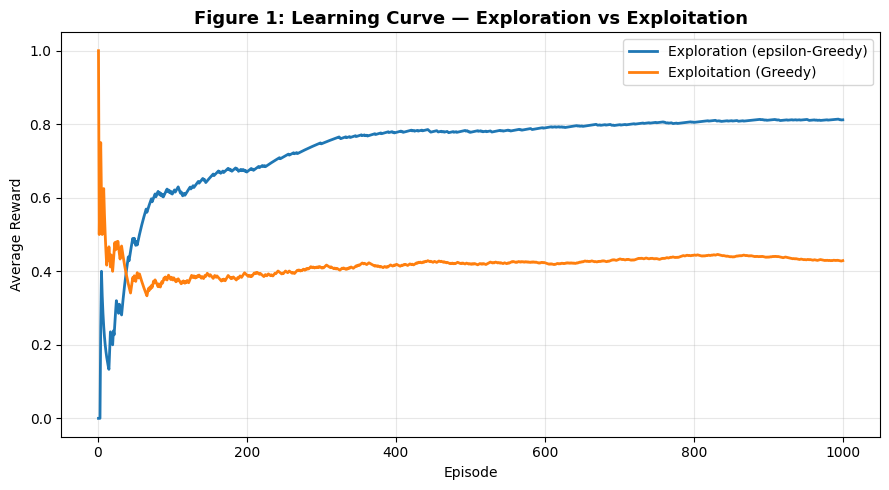

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(comparison_df["Episode"], exploration_result["avg_rewards"],
        color="tab:blue", label="Exploration (epsilon-Greedy)", linewidth=2)
ax.plot(comparison_df["Episode"], exploitation_result["avg_rewards"],
        color="tab:orange", label="Exploitation (Greedy)", linewidth=2)

ax.set_xlabel("Episode")
ax.set_ylabel("Average Reward")
ax.set_title("Figure 1: Learning Curve — Exploration vs Exploitation", fontsize=13, fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Figure 2: Total Reward Comparison

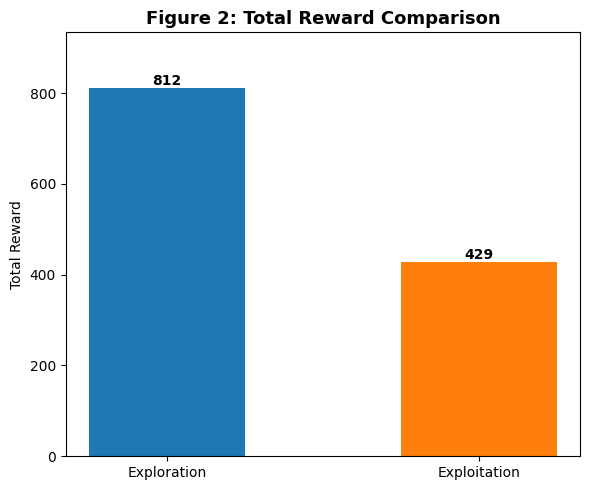

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))

labels = ["Exploration", "Exploitation"]
totals = [exploration_result["total_reward"], exploitation_result["total_reward"]]
colors = ["tab:blue", "tab:orange"]

bars = ax.bar(labels, totals, color=colors, width=0.5)
for bar, val in zip(bars, totals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
             str(val), ha="center", fontweight="bold")

ax.set_ylabel("Total Reward")
ax.set_title("Figure 2: Total Reward Comparison", fontsize=13, fontweight="bold")
ax.set_ylim(0, max(totals) * 1.15)

plt.tight_layout()
plt.show()


### Figure 3: Arm Selection Frequency

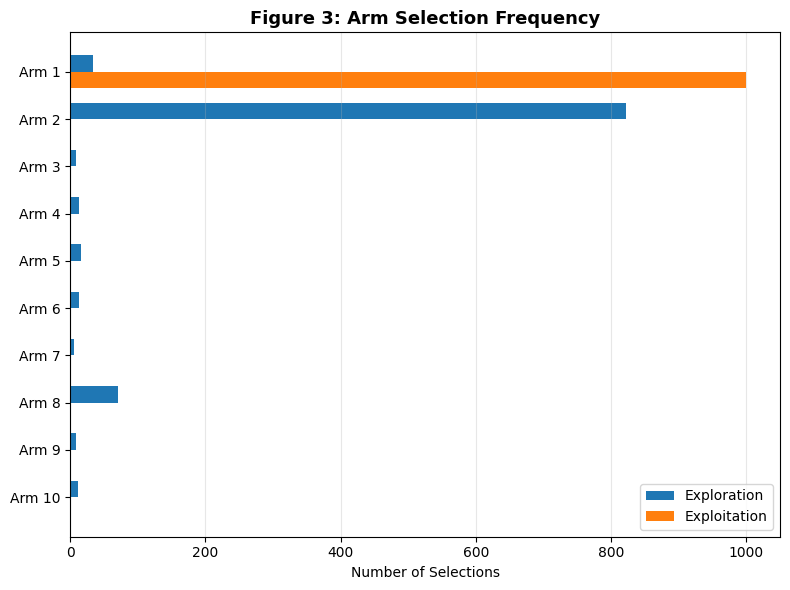

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))

arm_labels = [f"Arm {i+1}" for i in range(N_ARMS)]
y_pos = np.arange(N_ARMS)
bar_height = 0.35

ax.barh(y_pos - bar_height / 2, exploration_result["arm_counts"],
        height=bar_height, color="tab:blue", label="Exploration")
ax.barh(y_pos + bar_height / 2, exploitation_result["arm_counts"],
        height=bar_height, color="tab:orange", label="Exploitation")

ax.set_yticks(y_pos)
ax.set_yticklabels(arm_labels)
ax.invert_yaxis()
ax.set_xlabel("Number of Selections")
ax.set_title("Figure 3: Arm Selection Frequency", fontsize=13, fontweight="bold")
ax.legend()
ax.grid(alpha=0.3, axis="x")

plt.tight_layout()
plt.show()
